# What is a Qubit?

### $$ |\psi\rangle = \alpha |0\rangle + \beta |1\rangle $$
### 1. $\{\alpha, \beta\} \in \mathbb{C}$
### 2. $|\alpha|^2+|\beta|^2 =1$ 


## if $|\alpha|^2+|\beta|^2 \neq 1$, then 
### $$ |\psi\rangle = \frac{\alpha}{\sqrt{|\alpha|^2+|\beta|^2}} |0\rangle + \frac{\beta}{\sqrt{|\alpha|^2+|\beta|^2}} |1\rangle $$

In [1]:
import numpy as np

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import StatePreparation
from qiskit_aer import QasmSimulator
from qiskit.visualization import plot_histogram

## Qubit Initialization

In [3]:
alpha = 400
beta = 400

ampl = [alpha, beta]

ampl_norm = ampl/np.linalg.norm(ampl)


In [4]:
ampl_norm

array([0.70710678, 0.70710678])

In [5]:
# create a quantum register
q = QuantumRegister(1, name = 'qubit')
#create a classical register
c = ClassicalRegister(1, name = 'bit')

# create first quantum circuit
qc = QuantumCircuit(q,c)
qc.append(StatePreparation(ampl_norm), q)

display(qc.draw(initial_state = True), Statevector(qc).draw('latex'))

┌────────────────────────────────────┐
qubit: |0>┤ State Preparation(0.70711,0.70711) ├
          └────────────────────────────────────┘
 bit: 0 1/══════════════════════════════════════

<IPython.core.display.Latex object>

In [6]:
qc.measure(q,c)

display(qc.draw())

┌────────────────────────────────────┐┌─┐
qubit: ┤ State Preparation(0.70711,0.70711) ├┤M├
       └────────────────────────────────────┘└╥┘
bit: 1/═══════════════════════════════════════╩═
                                              0

In [10]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc, shots = 2000)
result = job.result()
counts = result.get_counts()
counts

{'1': 984, '0': 1016}

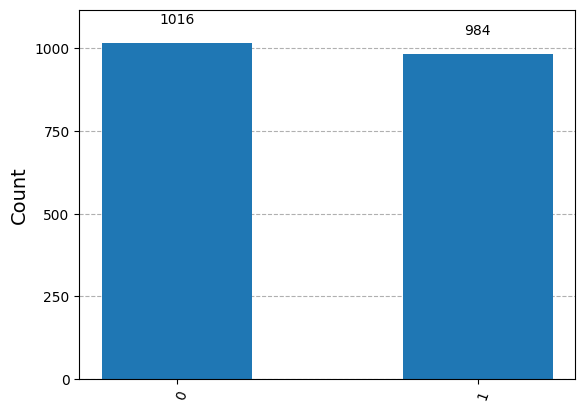

In [11]:
plot_histogram(counts)